In [1]:
# Check GPU

import torch

print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("Torch:", torch.__version__)

CUDA: True
GPU: Tesla T4
Torch: 2.11.0+cu128


In [2]:
# Install compatible libraries

!pip -q install \
transformers==4.53.0 \
datasets==3.6.0 \
accelerate==1.8.1 \
evaluate==0.4.5 \
scikit-learn==1.7.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.3/365.3 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 131.2 MB/s eta 0:00:00


In [3]:
# Upload dataset ZIP

from google.colab import files

uploaded = files.upload()

Saving RAGTruth-main.zip to RAGTruth-main.zip


In [8]:
# Extract ZIP

import zipfile

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name,"r") as zip_ref:
    zip_ref.extractall()

print("Extraction Complete")

Extraction Complete


In [9]:
# Show extracted folder structure

import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".jsonl"):
            print(os.path.join(root, file))

./RAGTruth-main/dataset/response.jsonl
./RAGTruth-main/dataset/source_info.jsonl


In [10]:
# Load the RAGTruth response dataset

import pandas as pd

df = pd.read_json(
    "./RAGTruth-main/dataset/response.jsonl",
    lines=True
)

print(df.shape)
df.head()

(17790, 8)


,id,source_id,model,temperature,labels,split,quality,response
0,0,15592,gpt-4-0613,0.7,[],train,good,The Anne Frank House has revealed that Anne Fr...
1,1,15592,gpt-3.5-turbo-0613,0.7,[],train,good,New research released by the Anne Frank House ...
2,2,15592,mistral-7B-instruct,0.7,"[{'start': 636, 'end': 653, 'text': 'February ...",train,good,New research conducted by the Anne Frank House...
3,3,15592,llama-2-7b-chat,0.7,"[{'start': 693, 'end': 754, 'text': 'Anne's di...",train,good,Here is a summary of the article in 115 words ...
4,4,15592,llama-2-13b-chat,0.7,[],train,good,"Seventy years ago, Anne Frank died of typhus i..."


In [11]:
# Display dataset columns

print(df.columns.tolist())

['id', 'source_id', 'model', 'temperature', 'labels', 'split', 'quality', 'response']


In [12]:
# Convert annotation lists into binary labels

print("Before Conversion:")
print(type(df["labels"].iloc[0]))
print(df["labels"].iloc[0])

df["labels"] = df["labels"].apply(lambda x: 1 if len(x) > 0 else 0)

print("\nAfter Conversion:")
print(df["labels"].value_counts())
print(df.head())

Before Conversion:
<class 'list'>
[]

After Conversion:
labels
0    10126
1     7664
Name: count, dtype: int64
   id  source_id                model  temperature  labels  split quality  \
0   0      15592           gpt-4-0613          0.7       0  train    good   
1   1      15592   gpt-3.5-turbo-0613          0.7       0  train    good   
2   2      15592  mistral-7B-instruct          0.7       1  train    good   
3   3      15592      llama-2-7b-chat          0.7       1  train    good   
4   4      15592     llama-2-13b-chat          0.7       0  train    good   

                                            response  
0  The Anne Frank House has revealed that Anne Fr...  
1  New research released by the Anne Frank House ...  
2  New research conducted by the Anne Frank House...  
3  Here is a summary of the article in 115 words ...  
4  Seventy years ago, Anne Frank died of typhus i...  


In [13]:
# Split dataset into training and validation sets

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["labels"]
)

print("Train Shape :", train_df.shape)
print("Validation Shape :", val_df.shape)

print("\nTrain Labels")
print(train_df["labels"].value_counts())

print("\nValidation Labels")
print(val_df["labels"].value_counts())

Train Shape : (14232, 8)
Validation Shape : (3558, 8)

Train Labels
labels
0    8101
1    6131
Name: count, dtype: int64

Validation Labels
labels
0    2025
1    1533
Name: count, dtype: int64


In [14]:
# Convert pandas DataFrames to Hugging Face Dataset

from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df, preserve_index=False)

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['id', 'source_id', 'model', 'temperature', 'labels', 'split', 'quality', 'response'],
    num_rows: 14232
})
Dataset({
    features: ['id', 'source_id', 'model', 'temperature', 'labels', 'split', 'quality', 'response'],
    num_rows: 3558
})


In [15]:
# Load DeBERTa-v3 tokenizer

from transformers import AutoTokenizer

MODEL_NAME = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Tokenizer Loaded Successfully


In [16]:
# Tokenize response text

MAX_LENGTH = 256

def tokenize(batch):
    return tokenizer(
        batch["response"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

print(train_dataset)

Map:   0%|          | 0/14232 [00:00<?, ? examples/s]

Map:   0%|          | 0/3558 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'source_id', 'model', 'temperature', 'labels', 'split', 'quality', 'response', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14232
})


In [17]:
# Keep only model input columns

train_dataset = train_dataset.remove_columns([
    "id",
    "source_id",
    "model",
    "temperature",
    "split",
    "quality",
    "response"
])

val_dataset = val_dataset.remove_columns([
    "id",
    "source_id",
    "model",
    "temperature",
    "split",
    "quality",
    "response"
])

print(train_dataset.features)

{'labels': Value(dtype='int64', id=None), 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'token_type_ids': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None), 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}


In [18]:
# Load DeBERTa-v3 model in float32

import torch
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "microsoft/deberta-v3-base"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    torch_dtype=torch.float32
)

model = model.float()
model.to("cuda")

print("Device :", next(model.parameters()).device)
print("Dtype  :", next(model.parameters()).dtype)

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device : cuda:0
Dtype  : torch.float32


In [19]:
# Verify dataset format

print(train_dataset.column_names)

sample = train_dataset[0]

for key, value in sample.items():
    if hasattr(value, "shape"):
        print(key, value.shape)
    else:
        print(key, value)

['labels', 'input_ids', 'token_type_ids', 'attention_mask']
labels 0
input_ids [1, 279, 1030, 8826, 262, 2372, 1712, 262, 3374, 907, 275, 3700, 261, 319, 284, 8096, 293, 262, 846, 261, 2425, 261, 1208, 261, 3491, 261, 2378, 263, 2439, 260, 279, 1806, 10258, 272, 262, 907, 490, 298, 333, 618, 264, 2642, 3700, 280, 268, 3374, 655, 263, 1279, 349, 264, 2006, 308, 2954, 260, 450, 327, 5118, 272, 262, 5511, 568, 269, 298, 18223, 618, 264, 1843, 3700, 292, 14107, 263, 272, 262, 658, 303, 266, 820, 265, 20557, 260, 4676, 261, 262, 1806, 2501, 272, 3700, 303, 1866, 264, 523, 7258, 1303, 263, 3472, 267, 70456, 1157, 267, 262, 1488, 438, 6800, 332, 787, 470, 260, 279, 1806, 3815, 272, 262, 907, 269, 298, 2770, 618, 263, 272, 278, 296, 1052, 3700, 264, 2275, 1455, 3374, 3681, 260, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [20]:
# Define evaluation metrics

import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision.compute(predictions=predictions, references=labels)["precision"],
        "recall": recall.compute(predictions=predictions, references=labels)["recall"],
        "f1": f1.compute(predictions=predictions, references=labels)["f1"],
    }

In [21]:
# Configure training arguments

from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./Hallucination_Model",

    overwrite_output_dir=True,

    num_train_epochs=5,

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="steps",

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    fp16=False,

    bf16=False,

    report_to="none"
)

In [22]:
# Create Hugging Face Trainer

from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

print("Trainer Ready")

Trainer Ready


In [23]:
# Train DeBERTa-v3 model

train_result = trainer.train()

print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.528200,0.537902,0.755200,0.805915,0.568819,0.666922
2,0.482300,0.539983,0.726251,0.655884,0.767123,0.707156
3,0.455600,0.502455,0.761102,0.730899,0.705153,0.717795
4,0.349800,0.677192,0.680157,0.586966,0.869537,0.700841
5,0.293300,0.823423,0.681563,0.587184,0.878669,0.703946


TrainOutput(global_step=4450, training_loss=0.42764539397164675, metrics={'train_runtime': 5396.3301, 'train_samples_per_second': 13.187, 'train_steps_per_second': 0.825, 'total_flos': 9361659237212160.0, 'train_loss': 0.42764539397164675, 'epoch': 5.0})


In [24]:
# Evaluate on validation set

metrics = trainer.evaluate()

for key, value in metrics.items():
    print(f"{key}: {value}")

eval_loss: 0.5024547576904297
eval_accuracy: 0.7611017425519955
eval_precision: 0.7308992562542258
eval_recall: 0.7051532941943901
eval_f1: 0.7177954847277557
eval_runtime: 82.0812
eval_samples_per_second: 43.347
eval_steps_per_second: 2.717
epoch: 5.0


In [25]:
# Predict validation labels

predictions = trainer.predict(val_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

In [26]:
# Generate classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7826    0.8035    0.7929      2025
           1     0.7309    0.7052    0.7178      1533

    accuracy                         0.7611      3558
   macro avg     0.7567    0.7543    0.7553      3558
weighted avg     0.7603    0.7611    0.7605      3558



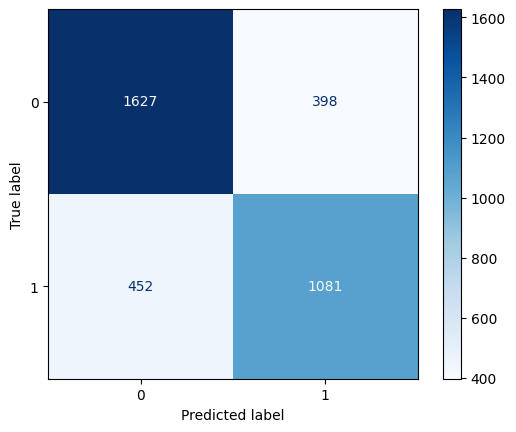

In [27]:
# Plot confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.show()

In [28]:
# Compute ROC-AUC

from sklearn.metrics import roc_auc_score

probs = predictions.predictions[:,1]

roc_auc = roc_auc_score(y_true, probs)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8355632867048391


In [29]:
# Display benchmark summary

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

benchmark = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred),
    "Recall": recall_score(y_true, y_pred),
    "F1 Score": f1_score(y_true, y_pred),
    "ROC-AUC": roc_auc
}

for k, v in benchmark.items():
    print(f"{k:<12}: {v:.4f}")

Accuracy    : 0.7611
Precision   : 0.7309
Recall      : 0.7052
F1 Score    : 0.7178
ROC-AUC     : 0.8356


In [30]:
# Save trained model and tokenizer

trainer.save_model("Hallucination_Model")

tokenizer.save_pretrained("Hallucination_Model")

print("Model Saved Successfully")

Model Saved Successfully


In [31]:
# Compress saved model

!zip -r Hallucination_Model.zip Hallucination_Model

  adding: Hallucination_Model/ (stored 0%)
  adding: Hallucination_Model/training_args.bin (deflated 54%)
  adding: Hallucination_Model/checkpoint-4450/ (stored 0%)
  adding: Hallucination_Model/checkpoint-4450/training_args.bin (deflated 54%)
  adding: Hallucination_Model/checkpoint-4450/scheduler.pt (deflated 61%)
  adding: Hallucination_Model/checkpoint-4450/trainer_state.json (deflated 77%)
  adding: Hallucination_Model/checkpoint-4450/config.json (deflated 53%)
  adding: Hallucination_Model/checkpoint-4450/rng_state.pth (deflated 26%)
  adding: Hallucination_Model/checkpoint-4450/optimizer.pt (deflated 43%)
  adding: Hallucination_Model/checkpoint-4450/model.safetensors (deflated 18%)
  adding: Hallucination_Model/spm.model (deflated 50%)
  adding: Hallucination_Model/tokenizer.json (deflated 77%)
  adding: Hallucination_Model/checkpoint-3560/ (stored 0%)
  adding: Hallucination_Model/checkpoint-3560/training_args.bin (deflated 54%)
  adding: Hallucination_Model/checkpoint-3560/sc

In [32]:
# Download trained model

from google.colab import files

files.download("Hallucination_Model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>